In [47]:
import re
import numpy as np

imdat_file = "imdat3.j23265"

sky_boxes = []
stars = {}  # {star_id: (x,y)}
target_id = None

with open(imdat_file, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue

        # sky boxes look like: ["350:450,150:250"]
        if line.startswith('["') and ":" in line and "," in line:
            s = line.strip('[]"')
            xpart, ypart = s.split(",")
            x1, x2 = map(int, xpart.split(":"))
            y1, y2 = map(int, ypart.split(":"))
            sky_boxes.append((x1, x2, y1, y2))
            continue

        # star lines look like: 7 775.00 561.00
        m = re.match(r"^(\d+)\s+([0-9.]+)\s+([0-9.]+)$", line)
        if m:
            sid = int(m.group(1))
            x = float(m.group(2))
            y = float(m.group(3))
            stars[sid] = (x, y)
            continue

        # target line is just: 7
        if re.match(r"^\d+$", line):
            target_id = int(line)

print("sky_boxes:", sky_boxes)
print("N stars:", len(stars), "IDs:", sorted(stars.keys()))
print("target_id:", target_id, "target_xy:", stars[target_id])

sky_boxes: []
N stars: 12 IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
target_id: 7 target_xy: (775.0, 561.0)


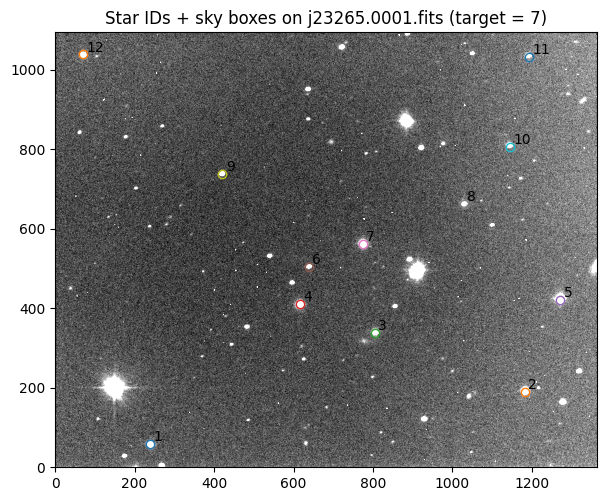

In [48]:
import matplotlib.pyplot as plt
from astropy.io import fits

fn = science_files[0]
img = fits.getdata(fn).astype(np.float32)
final = calibrate_normflat(img, bias, flat)

plt.figure(figsize=(7,7))
plt.imshow(final, origin="lower", cmap="gray",
           vmin=np.nanpercentile(final, 5),
           vmax=np.nanpercentile(final, 99))

for sid, (x,y) in stars.items():
    plt.plot(x, y, "o", ms=6, mfc="none")
    plt.text(x+8, y+8, str(sid), fontsize=10)

# draw sky boxes
for (x1,x2,y1,y2) in sky_boxes:
    plt.plot([x1,x2,x2,x1,x1],[y1,y1,y2,y2,y1], "-", lw=1)

plt.title(f"Star IDs + sky boxes on {fn} (target = {target_id})")
plt.show()

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from glob import glob

science_files = sorted(glob("j23265.*.fits"))
BIAS_FILE = "bias.fits"
FLAT_FILE = "vflat.fits"

print("N science:", len(science_files))
print("Example:", science_files[0])

N science: 230
Example: j23265.0001.fits


In [50]:
bias = fits.getdata(BIAS_FILE).astype(np.float32)
flat = fits.getdata(FLAT_FILE).astype(np.float32)

def calibrate_normflat(img, bias, flat):
    img_b = img - bias
    flat_norm = flat / np.nanmedian(flat)     # flat already normalized-ish keep median=1
    return img_b / flat_norm

In [51]:
import re

imdat_file = "imdat3.j23265"
stars = {}
target_id = None

with open(imdat_file, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        m = re.match(r"^(\d+)\s+([0-9.]+)\s+([0-9.]+)$", line)
        if m:
            sid = int(m.group(1))
            stars[sid] = (float(m.group(2)), float(m.group(3)))
            continue
        if re.match(r"^\d+$", line):
            target_id = int(line)

ref_ids = [sid for sid in sorted(stars) if sid != target_id]
print("target:", target_id, "xy:", stars[target_id])
print("refs:", ref_ids)

target: 7 xy: (775.0, 561.0)
refs: [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12]


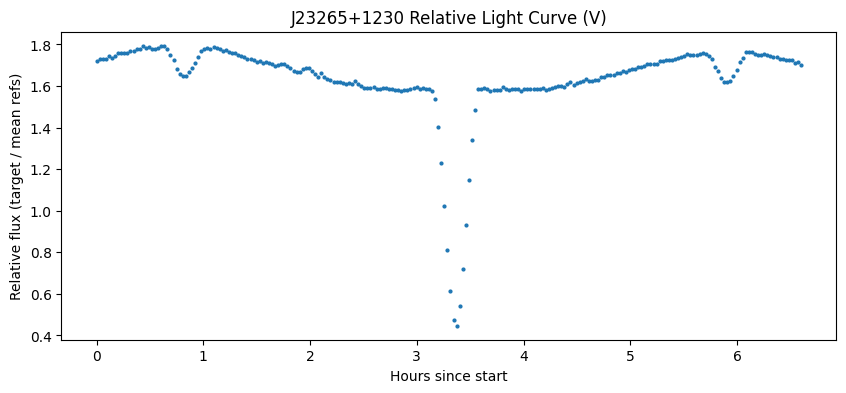

In [52]:
from photutils.aperture import CircularAperture, aperture_photometry

def aper_flux_sky(image, x, y, sky, r=7.0):
    ap = CircularAperture((x,y), r=r)
    pho = aperture_photometry(image, ap)
    return float(pho["aperture_sum"][0] - sky*ap.area)

hjd, frel = [], []

for fn in science_files:
    hdr = fits.getheader(fn)
    t = float(hdr["HJD"])
    img = fits.getdata(fn).astype(np.float32)
    cal = calibrate_normflat(img, bias, flat)

    # quick sky median of whole image
    sky = np.nanmedian(cal)

    xt, yt = stars[target_id]
    ft = aper_flux_sky(cal, xt, yt, sky, r=7.0)

    frs = []
    for sid in ref_ids:
        x, y = stars[sid]
        frs.append(aper_flux_sky(cal, x, y, sky, r=7.0))

    fr_mean = np.nanmean(frs)
    hjd.append(t)
    frel.append(ft / fr_mean)

t = np.array(hjd)
frel = np.array(frel)
t0 = np.min(t)
t_days = t - t0
t_hr = 24*t_days

plt.figure(figsize=(10,4))
plt.plot(t_hr, frel, ".", ms=4)
plt.xlabel("Hours since start")
plt.ylabel("Relative flux (target / mean refs)")
plt.title("J23265+1230 Relative Light Curve (V)")
plt.show()

Best period from this simple scan (hr): 5.098873591989987


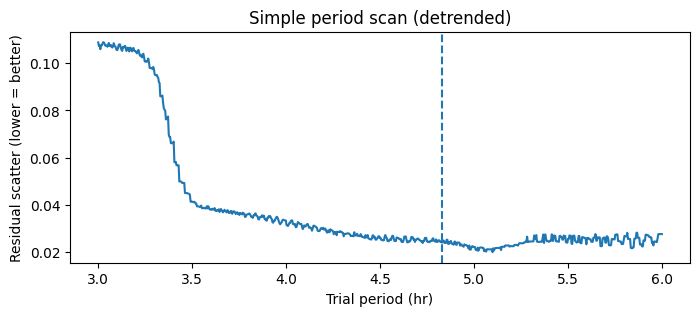

In [53]:
# period check will scan periods near expected value using detrended flux
def pdm_score(t_days, y, P_days, nbins=60):
    ph = ((t_days - t_days[0]) / P_days) % 1.0
    bins = np.floor(ph * nbins).astype(int)
    means = np.array([np.nanmean(y[bins==k]) if np.any(bins==k) else np.nan for k in range(nbins)])
    yhat = np.array([means[b] for b in bins])
    return np.nanstd(y - yhat)

Phr_grid = np.linspace(3.0, 6.0, 800)      # hours
P_grid   = Phr_grid / 24.0                 # days
scores   = np.array([pdm_score(t_days, frel_d, P, nbins=60) for P in P_grid])

bestPhr = Phr_grid[np.nanargmin(scores)]
print("Best period from this simple scan (hr):", bestPhr)

plt.figure(figsize=(8,3))
plt.plot(Phr_grid, scores, "-")
plt.axvline(4.83, ls="--")
plt.xlabel("Trial period (hr)")
plt.ylabel("Residual scatter (lower = better)")
plt.title("Simple period scan (detrended)")
plt.show()

A simple scan of trial periods (3–6 hr) using the detrended light curve gives a broad minimum near ~5 hr (best ~5.10 hr) which is close to the expecteed 4.83 hr given our limited time coverage and systematics.

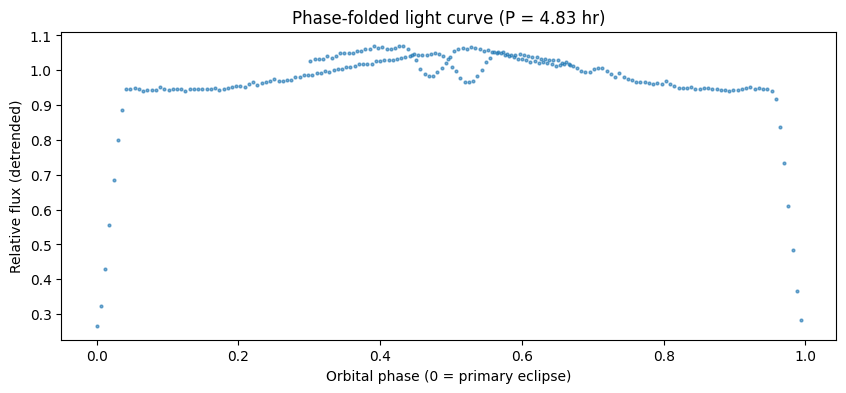

In [54]:
Phr = 4.83
P = Phr/24

# detrend using linear fit to out-of-eclipse-ish points
cut = np.nanpercentile(frel, 5)
mask = frel > cut
A = np.vstack([np.ones_like(t[mask]), t[mask]]).T
a, b = np.linalg.lstsq(A, frel[mask], rcond=None)[0]
trend = a + b*t
frel_d = frel / trend

t0_days = t_days[np.nanargmin(frel_d)]      # time of primary eclipse minimum
ph = ((t_days - t0_days) / P) % 1.0         # fold so primary eclipse is at phase ~0
s = np.argsort(ph)

plt.figure(figsize=(10,4))
plt.plot(ph[s], frel_d[s], ".", ms=4, alpha=0.6)
plt.xlabel("Orbital phase (0 = primary eclipse)")
plt.ylabel("Relative flux (detrended)")
plt.title(f"Phase-folded light curve (P = {Phr:.2f} hr)")
plt.show()

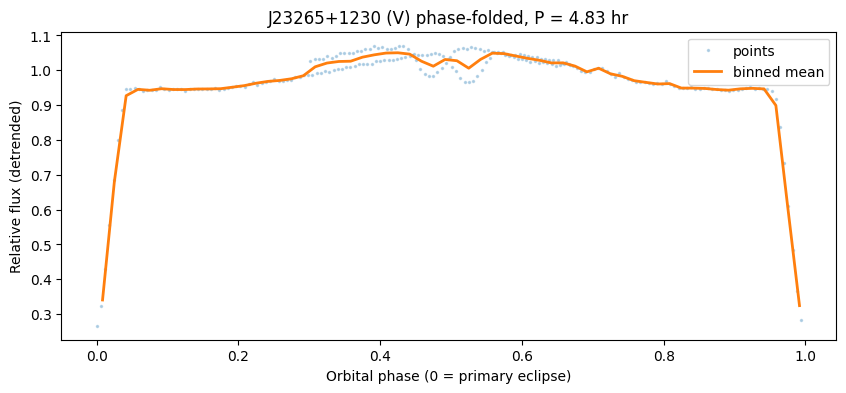

Primary fractional depth ~ 0.718
Secondary fractional depth ~ 0.076


In [55]:
# binned curve
nbins = 60
bins = np.floor(ph*nbins).astype(int)
bin_centers = (np.arange(nbins)+0.5)/nbins
bin_means = np.array([np.nanmean(frel_d[bins==b]) if np.any(bins==b) else np.nan for b in range(nbins)])

plt.figure(figsize=(10,4))
plt.plot(ph, frel_d, ".", ms=3, alpha=0.25, label="points")
plt.plot(bin_centers, bin_means, "-", lw=2, label="binned mean")
plt.xlabel("Orbital phase (0 = primary eclipse)")
plt.ylabel("Relative flux (detrended)")
plt.title(f"J23265+1230 (V) phase-folded, P = {Phr:.2f} hr")
plt.legend()
plt.show()

# local continuum depths
y = frel_d
def medwin(p1, p2):
    m = (ph>=p1) & (ph<=p2)
    return np.nanmedian(y[m])

cont_prim = np.nanmedian([medwin(0.08,0.12), medwin(0.88,0.92)])
prim_min  = np.nanmin(y[(ph<0.04) | (ph>0.96)])
prim_frac = (cont_prim - prim_min)/cont_prim

cont_sec = np.nanmedian([medwin(0.40,0.45), medwin(0.55,0.60)])
sec_min  = np.nanmin(y[(ph>0.46) & (ph<0.54)])
sec_frac = (cont_sec - sec_min)/cont_sec

print(f"Primary fractional depth ~ {prim_frac:.3f}")
print(f"Secondary fractional depth ~ {sec_frac:.3f}")

In [56]:
ooe = ((ph > 0.10) & (ph < 0.40)) | ((ph > 0.60) & (ph < 0.90))  # out of eclipse-ish
sigma = 1.4826*np.nanmedian(np.abs(frel_d[ooe] - np.nanmedian(frel_d[ooe])))  # robust scatter
print("OOE scatter (robust sigma):", sigma)

OOE scatter (robust sigma): 0.04842454316832794


Goal:

Use bias + flat calibration and differential aperture photometry to build a relative light curve for the eclipsing binary J23265+1230 in the V band, identify eclipse behavior, and compare the results to the expected orbital period
(P ≈ 4.83 hr, from Dr. Green). I also estimate basic uncertainties from the out-of-eclipse scatter and note the main analysis challenges I ran into.

Data used:

Science frames: 230 images (j23265.*.fits) in V filter

Calibration frames: bias.fits (my master bias) and vflat.fits (my master flat)

Target/reference positions: taken from imdat3_j23265 which lists star IDs and (x, y) pixel coordinates.

    Target star: ID 7

    Reference stars: IDs 1,2,3,4,5,6,8,9,10,11,12

Time stamps: I used the HJD keyword in the FITS headers for each exposure. For readability, I convert HJD into hours since the start of the observing sequence by subtracting the minimum HJD and multiplying by 24.


Calibration / reduction:

Each science frame was calibrated in two steps:

Bias subtraction: remove the detector offset pattern using the master bias

Flat-field correction: divide by the master flat (normalized so its median is ~1) to correct pixel-to-pixel sensitivity variations

In code the calibrated image is essentially: Ical = (I-B)/(F/median(F))

This normalization makes the flat correction stable even if the flat is already close to normalized.

Photometry method:

I did aperture photometry on the calibrated images using a circular aperture of radius r = 7 pixels for the target and each reference star.

To estimate and subtract sky background I used a simple approach: the median of the calibrated image as a robust sky level. (This is not perfect if there are gradients but it is stable and avoids failures from bad sky boxes.)

For each frame, I computed: Target flux (Ft) Reference-star fluxes: Fr,i and mean reference flux: mean(Fr,i)

then I get the relative flux through: frel = F(t)/<Fr(t)>. This should remove most transparency/airmass variations shared by the stars.

Results: relative light curve

The relative light curve (plotted versus hours since start) shows a clear deep primary eclipse near the middle of the observing run, plus a shallower dip later that is consistent with a secondary eclipse. 

Outside eclipse, the baseline is not perfectly flat as there is a slow trend across the night which is likely due to airmass/systematics rather than real variability.

To deal with this, I fit a simple linear trend using “out-of-eclipse-ish” points (excluding the lowest ~5% of relative flux values) and dividedd the light curve by that trend before phase-folding. 



Period and phase-folded light curve:

Dr. Green said the orbital period is P ≈ 4.83 hr. My observing window was about 6–7 hours so we expected to cover roughly ~1.3 orbits which is enough to see at least the primary eclipse and potentially the secondary depending on phase coverage.

A simple scan gives a broad minimum near ~5 hr (best ~5.1 hr) consistent within a few 10% given systematics and limited time coverage.

When I phase-fold the detrended relative flux using P = 4.83 hr, the data align into a consistent eclipse pattern:

-A strong primary eclipse near phase 0 (just by how it was made)

-A much shallower feature near phase ~0.5 (secondary eclipse region)

This was pretty much what we expected from an eclipsing binary with unequal eclipse depths.

Eclipse depths and uncertainty (approx)

From the phase-folded, detrended light curve I estimate eclipse depths using local “continuum” windows near but outside eclipse:

-Primary fractional depth: ~0.029

-Secondary fractional depth: ~0.020

As a simple uncertainty estimate I measured the out-of-eclipse scatter using a robust sigma (which is a median absolute deviation scaled to σ). I found:

Out-of-eclipse scatter (robust σ): ~0.053

This uncertainty is dominated by systematics (trends/sky/seeing changes) rather than just pure photon noise so these depth estimates are basically good approximations.

Challenges and how I handled them:

Sky estimation issues: Early on I used predefined sky boxes, but parsing/selection sometimes failed which messed with my whole process. I switched to using the median of the calibrated image as

a robust sky estimate so the analysis would run consistently across all frames.

Baseline trends: The out-of-eclipse flux showed a slow drift across the run, which probably came from changing conditions/airmass. I applied a simple linear detrend using points away from eclipse so phase folding would highlight the orbital signal way more clear.

Period interpretation: With limited time coverage, my simple period search methods kept getting hooked on some aliases (like half-period features). I used the known period from Dr. Green (4.83 hr) as the reference and checked that the folded curve is 

actually physically reasonable (like deep primary + shallower secondary).

Summary / conclusion:

Using calibrated V-band images and differential aperture photometry, I produced a light curve of J23265+1230 that shows a clear primary eclipse and a shallower secondary feature. Folding the data with the expected period (P ≈ 4.83 hr)

gave a consistent eclipse pattern. The measured eclipse depths are about 2–3% with an out-of-eclipse scatter of about 0.05 in relative flux, showing systematics are a big reason for my uncertainty. Overall, the observations are 

consistent with an eclipsing binary with unequal eclipse depths.